# 02 - Exploratory Data Analysis

Explores the Yelp reviews dataset to understand distributions, quality, and patterns before feature engineering.

Uses 2019 data (~907k rows) queried via Athena.

## 0. Setup

In [1]:
import boto3
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load shared config from 01_setup_athena.ipynb
with open('project_config.json') as f:
    cfg = json.load(f)

REGION        = cfg['REGION']
GLUE_DB       = cfg['GLUE_DB']
ATHENA_RESULTS = cfg['ATHENA_RESULTS']
SOURCE_BUCKET = cfg['SOURCE_BUCKET']

session = boto3.Session(region_name=REGION)
athena  = session.client('athena')

sns.set_theme(style='whitegrid')
print('Setup complete')

Setup complete


## 1. Load Data via Athena

In [2]:
def run_athena_query(sql):
    response = athena.start_query_execution(
        QueryString=sql,
        QueryExecutionContext={'Database': GLUE_DB},
        ResultConfiguration={'OutputLocation': ATHENA_RESULTS}
    )
    query_id = response['QueryExecutionId']
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state  = status['QueryExecution']['Status']['State']
        if state == 'SUCCEEDED':
            break
        elif state in ['FAILED', 'CANCELLED']:
            reason = status['QueryExecution']['Status']['StateChangeReason']
            raise Exception(f'Query {state}: {reason}')
        time.sleep(2)
    # Paginate results
    rows, next_token = [], None
    while True:
        kwargs = {'QueryExecutionId': query_id}
        if next_token:
            kwargs['NextToken'] = next_token
        page = athena.get_query_results(**kwargs)
        rows.extend(page['ResultSet']['Rows'])
        next_token = page.get('NextToken')
        if not next_token:
            break
    # Convert to dataframe
    headers = [c['VarCharValue'] for c in rows[0]['Data']]
    data    = [[c.get('VarCharValue', '') for c in row['Data']] for row in rows[1:]]
    return pd.DataFrame(data, columns=headers)

print('Athena helper ready')

Athena helper ready


In [3]:
# Load full 2019 dataset via Athena
# Note: this may take 1-2 minutes to download ~907k rows
print('Loading 2019 data...')
df = run_athena_query('SELECT * FROM yelp_reviews_2019')

# Fix dtypes — Athena returns everything as string
df['stars']  = pd.to_numeric(df['stars'])
df['useful'] = pd.to_numeric(df['useful'])
df['funny']  = pd.to_numeric(df['funny'])
df['cool']   = pd.to_numeric(df['cool'])
df['date']   = pd.to_datetime(df['date'])

print(f'Loaded {len(df):,} rows')
print(f'Columns: {list(df.columns)}')

Loading 2019 data...


Loaded 907,284 rows
Columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


## 2. Basic Statistics

In [4]:
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Numeric summary:')
df[['stars', 'useful', 'funny', 'cool']].describe()

Shape: (907284, 9)

Dtypes:
review_id              object
user_id                object
business_id            object
stars                   int64
useful                  int64
funny                   int64
cool                    int64
text                   object
date           datetime64[ns]
dtype: object

Numeric summary:


,stars,useful,funny,cool
count,907284.000000,907284.000000,907284.000000,907284.000000
mean,3.766577,0.953188,0.229216,0.470235
std,1.544170,2.904024,1.443785,2.394287
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,5.000000,0.000000,0.000000,0.000000
75%,5.000000,1.000000,0.000000,0.000000
max,5.000000,325.000000,180.000000,304.000000


## 3. Missing Values

In [5]:
null_counts = df.isnull().sum()
empty_text  = (df['text'].str.strip() == '').sum()

print('Null counts per column:')
print(null_counts)
print(f'\nEmpty text (whitespace only): {empty_text}')
print(f'Duplicate review_ids: {df["review_id"].duplicated().sum()}')

Null counts per column:
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

Empty text (whitespace only): 0
Duplicate review_ids: 0


## 4. Star Rating Distribution

Key for rating prediction — check if classes are balanced.

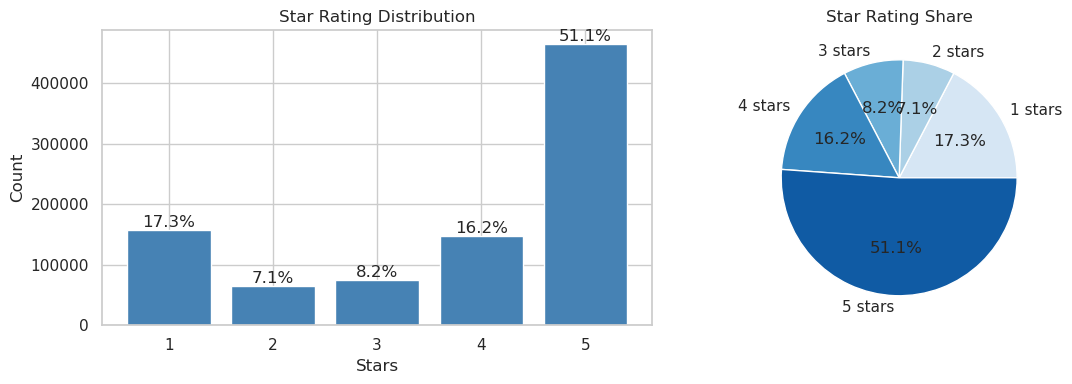


Class balance:
stars
1    157311
2     64658
3     74458
4    146931
5    463926
Name: count, dtype: int64

Note: imbalanced classes will need to be handled in feature engineering


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
star_counts = df['stars'].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values, color='steelblue')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')
axes[0].set_title('Star Rating Distribution')
for i, (star, count) in enumerate(star_counts.items()):
    axes[0].text(star, count, f'{count/len(df)*100:.1f}%', ha='center', va='bottom')

# Pie chart
axes[1].pie(star_counts.values, labels=[f'{s} stars' for s in star_counts.index],
            autopct='%1.1f%%', colors=sns.color_palette('Blues', 5))
axes[1].set_title('Star Rating Share')

plt.tight_layout()
plt.savefig('eda_stars_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nClass balance:')
print(star_counts)
print(f'\nNote: imbalanced classes will need to be handled in feature engineering')

## 5. Review Text Analysis

Review length is a useful feature — longer reviews may correlate with extreme ratings.

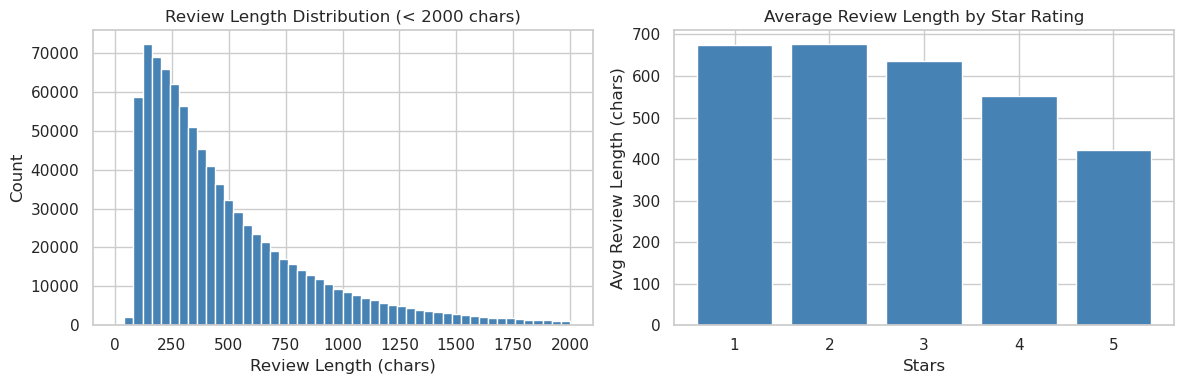

Review length stats:
count    907284.000000
mean        522.849339
std         484.366233
min           1.000000
25%         215.000000
50%         375.000000
75%         659.000000
max        5000.000000
Name: review_length, dtype: float64

Word count stats:
count    907284.000000
mean         96.656938
std          90.375650
min           1.000000
25%          39.000000
50%          69.000000
75%         122.000000
max        1070.000000
Name: word_count, dtype: float64


In [7]:
df['review_length'] = df['text'].str.len()
df['word_count']    = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Review length distribution (cap at 2000 chars for readability)
df[df['review_length'] < 2000]['review_length'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Review Length (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Review Length Distribution (< 2000 chars)')

# Average review length by star rating
avg_length = df.groupby('stars')['review_length'].mean()
axes[1].bar(avg_length.index, avg_length.values, color='steelblue')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Avg Review Length (chars)')
axes[1].set_title('Average Review Length by Star Rating')

plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=100, bbox_inches='tight')
plt.show()

print('Review length stats:')
print(df['review_length'].describe())
print(f'\nWord count stats:')
print(df['word_count'].describe())

## 6. Reviews Over Time

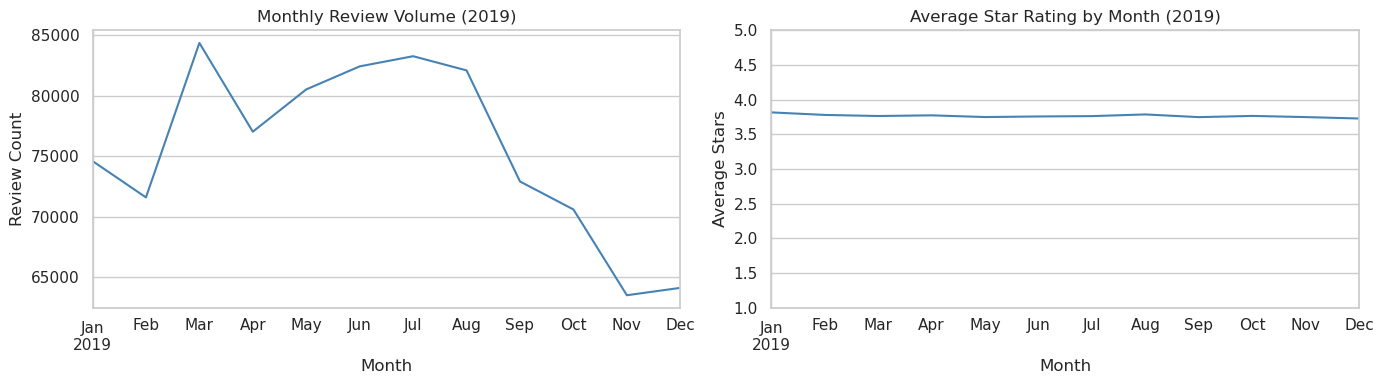

In [8]:
df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby('month').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly review count
monthly.plot(ax=axes[0], color='steelblue')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Review Count')
axes[0].set_title('Monthly Review Volume (2019)')

# Average stars over time
monthly_stars = df.groupby('month')['stars'].mean()
monthly_stars.plot(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Stars')
axes[1].set_title('Average Star Rating by Month (2019)')
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig('eda_time_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Engagement Features (useful, funny, cool)

These may correlate with review quality and star ratings.

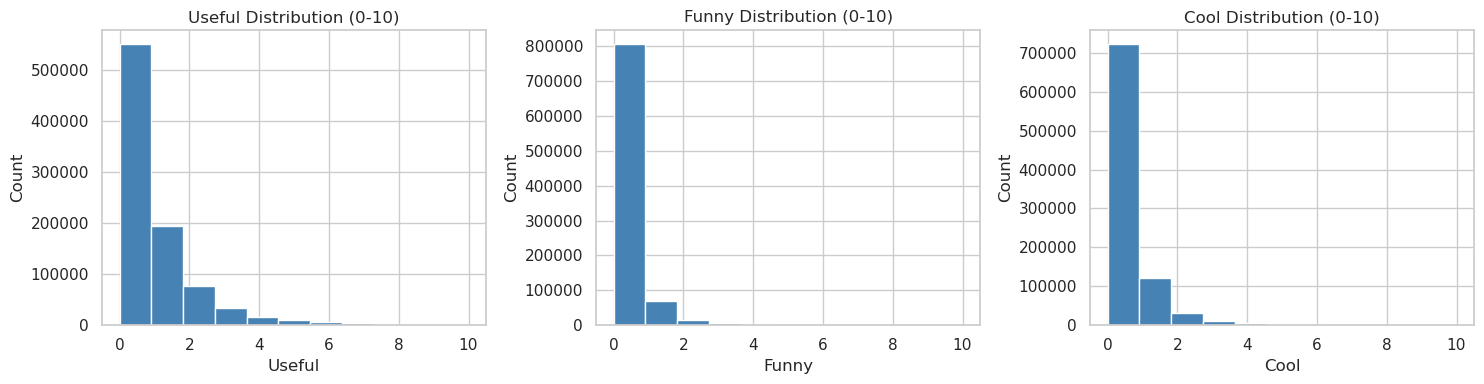

Correlation with star rating:
stars            1.000000
useful          -0.054666
funny           -0.025340
cool             0.065780
review_length   -0.216423
word_count      -0.227721
Name: stars, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['useful', 'funny', 'cool']):
    # Cap at 10 for readability — most values are 0-5
    df[df[col] <= 10][col].hist(bins=11, ax=ax, color='steelblue')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')
    ax.set_title(f'{col.capitalize()} Distribution (0-10)')

plt.tight_layout()
plt.savefig('eda_engagement.png', dpi=100, bbox_inches='tight')
plt.show()

# Correlation with stars
print('Correlation with star rating:')
print(df[['stars', 'useful', 'funny', 'cool', 'review_length', 'word_count']].corr()['stars'])

## 8. Top Businesses

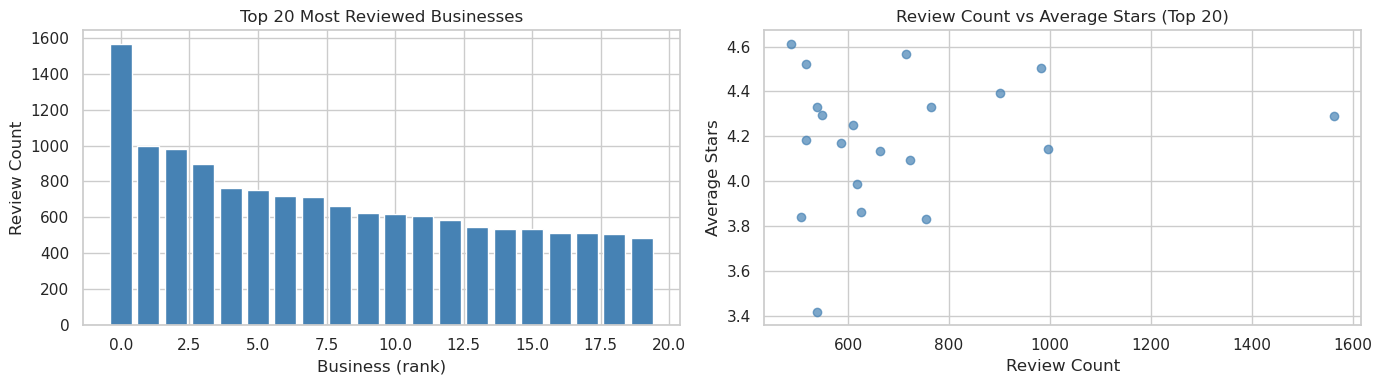

Total unique businesses: 101,959


Total unique users: 431,436


In [10]:
top_businesses = df.groupby('business_id').agg(
    review_count=('review_id', 'count'),
    avg_stars=('stars', 'mean')
).sort_values('review_count', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(20), top_businesses['review_count'], color='steelblue')
axes[0].set_xlabel('Business (rank)')
axes[0].set_ylabel('Review Count')
axes[0].set_title('Top 20 Most Reviewed Businesses')

axes[1].scatter(top_businesses['review_count'], top_businesses['avg_stars'],
                color='steelblue', alpha=0.7)
axes[1].set_xlabel('Review Count')
axes[1].set_ylabel('Average Stars')
axes[1].set_title('Review Count vs Average Stars (Top 20)')

plt.tight_layout()
plt.savefig('eda_businesses.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Total unique businesses: {df["business_id"].nunique():,}')
print(f'Total unique users: {df["user_id"].nunique():,}')

## 9. EDA Summary

In [11]:
print('=== EDA Summary ===')
print(f'Total reviews        : {len(df):,}')
print(f'Null values          : {df.isnull().sum().sum()}')
print(f'Duplicate review_ids : {df["review_id"].duplicated().sum()}')
print(f'Empty text reviews   : {(df["text"].str.strip() == "").sum()}')
print(f'Star rating mean     : {df["stars"].mean():.2f}')
print(f'Star rating std      : {df["stars"].std():.2f}')
print(f'Avg review length    : {df["review_length"].mean():.0f} chars')
print(f'Avg word count       : {df["word_count"].mean():.0f} words')
print(f'Unique businesses    : {df["business_id"].nunique():,}')
print(f'Unique users         : {df["user_id"].nunique():,}')
print()
print('Class distribution (stars):')
print(df['stars'].value_counts().sort_index())
print()
print('Issues to address in 03_data_cleaning.ipynb:')
issues = []
if df.isnull().sum().sum() > 0:
    issues.append('  - Null values found')
if (df['text'].str.strip() == '').sum() > 0:
    issues.append('  - Empty text reviews found')
if df['review_id'].duplicated().sum() > 0:
    issues.append('  - Duplicate review_ids found')
star_pcts = df['stars'].value_counts(normalize=True)
if star_pcts.max() > 0.4:
    issues.append(f'  - Class imbalance: {star_pcts.idxmax()} stars dominates at {star_pcts.max()*100:.1f}%')
if issues:
    for issue in issues:
        print(issue)
else:
    print('  - No major issues found')

=== EDA Summary ===
Total reviews        : 907,284


Null values          : 0
Duplicate review_ids : 0


Empty text reviews   : 0
Star rating mean     : 3.77
Star rating std      : 1.54
Avg review length    : 523 chars
Avg word count       : 97 words


Unique businesses    : 101,959


Unique users         : 431,436

Class distribution (stars):
stars
1    157311
2     64658
3     74458
4    146931
5    463926
Name: count, dtype: int64

Issues to address in 03_data_cleaning.ipynb:


  - Class imbalance: 5 stars dominates at 51.1%
